# Permutation Experiment Analysis

Analysis of the most recent permutation experiment: **permuting back, 10 instance, full permutation, 4 clients**

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Load Experiment Data

In [3]:
# Load the most recent experiment results
exp_path = Path("experimental_logs/permuting back, 10 instance, full permutation, 4 clients")
results_file = exp_path / "permutation_test_results.json"

with open(results_file, "r") as f:
    data = json.load(f)

print("Experiment loaded successfully!")
print(f"Total permutations tested: {data['summary']['total_permutations']:,}")

Experiment loaded successfully!
Total permutations tested: 7,398,840


## Overall Summary Statistics

In [4]:
summary = data["summary"]

print("=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)
print(f"\nTotal Permutations: {summary['total_permutations']:,}")
print("\nToken Usage:")
print(f"  - Input tokens:  {summary['token_usage']['total_input_tokens']:,}")
print(f"  - Output tokens: {summary['token_usage']['total_output_tokens']:,}")
print(f"  - Total tokens:  {summary['token_usage']['total_tokens']:,}")
print("\nSemantic Consistency:")
print(f"  - Avg consistency: {summary['semantic_consistency']['avg_consistency']:.2%}")
print(f"  - Total unique responses: {summary['semantic_consistency']['total_unique_responses']}")
print("\nSame-Position Selection Rate (lower is better):")
print(f"  - Avg rate: {summary['positional_bias']['avg_consistency']:.2%}")
print(f"  - Total unique position patterns: {summary['positional_bias']['total_unique_responses']}")

EXPERIMENT SUMMARY

Total Permutations: 7,398,840

Token Usage:
  - Input tokens:  6,908,308,200
  - Output tokens: 234,339,705
  - Total tokens:  7,142,647,905

Semantic Consistency:
  - Avg consistency: 46.49%
  - Total unique responses: 2359

Same-Position Selection Rate (lower is better):
  - Avg rate: 42.40%
  - Total unique position patterns: 2889


## Per-Instance Analysis

In [5]:
# Extract per-instance metrics
instances_data = []

for inst in data["instances"]:
    instances_data.append(
        {
            "instance_idx": inst["instance_idx"],
            "id": inst["id"],
            "question": inst["question"][:100] + "..." if len(inst["question"]) > 100 else inst["question"],
            "num_rows": inst["num_rows"],
            "num_permutations": inst["num_permutations"],
            "semantic_consistency": inst["semantic_consistency"]["consistency_percentage"],
            "semantic_unique_responses": inst["semantic_consistency"]["num_unique_responses"],
            "same_position_selection_rate": inst["positional_bias"]["consistency_percentage"],
            "positional_unique_responses": inst["positional_bias"]["num_unique_responses"],
            "input_tokens": inst["token_usage"]["total_input_tokens"],
            "output_tokens": inst["token_usage"]["total_output_tokens"],
        }
    )

df_instances = pd.DataFrame(instances_data)
df_instances

,instance_idx,id,question,num_rows,num_permutations,semantic_consistency,semantic_unique_responses,same_position_selection_rate,positional_unique_responses,input_tokens,output_tokens
0,0,nt-0,what was the last year where this team was a p...,10,3628800,0.151970,1249,0.239708,1229,3545337600,114800388
1,1,nt-5,how many people stayed at least 3 years in off...,7,5040,0.625794,118,0.625794,122,4434480,403159
2,2,nt-11,what was the first venue for the asian games?,10,3628800,0.492699,384,0.244692,673,3236889600,113250928
3,3,nt-19,in how many games did the winning team score m...,8,40320,0.468800,200,0.027902,258,34473600,775935
4,4,nt-20,which album released by the band schnell fenst...,5,120,0.741667,12,0.741667,11,91080,6694
5,5,nt-22,which ship in auckland had the fastest speed i...,7,5040,0.230952,61,0.230952,78,4829040,123954
6,6,nt-23,what counties had the least participants for t...,8,40320,0.324727,239,0.323983,354,31248000,2704583
7,7,nt-25,what's the number of parishes founded in the 1...,7,5040,0.307937,60,0.122619,107,4072320,135182
8,8,nt-32,which name is first on the chart,7,5040,0.306746,9,0.684722,9,4999680,116950
9,9,nt-38,how many consecutive friendly competitions did...,8,40320,0.997569,27,0.997569,48,41932800,2021932


## Permutation Sensitivity Analysis

In [6]:
# Answer variance across permutations - both position space and semantic space
print("=" * 80)
print("PERMUTATION SENSITIVITY: Answer Variance Across Permutations")
print("=" * 80)

for inst in data["instances"]:
    print(f"\n{'=' * 80}")
    print(f"Instance {inst['instance_idx']}: {inst['id']}")
    print(f"Question: {inst['question']}")
    print(f"{'=' * 80}")
    print(f"Table size: {inst['num_rows']} rows")
    print(f"Total permutations: {inst['num_permutations']:,}")

    # Semantic space analysis (after permuting back)
    semantic_unique = inst["semantic_consistency"]["num_unique_responses"]
    semantic_consistency = inst["semantic_consistency"]["consistency_percentage"]
    semantic_variance = 1 - semantic_consistency

    print("\n📊 SEMANTIC SPACE (after permuting back - content-based):")
    print(f"  - Unique answers: {semantic_unique:,}")
    print(f"  - Most common answer: {inst['semantic_consistency']['most_common_response']}")
    print(f"  - Consistency (same answer): {semantic_consistency:.2%}")
    print(f"  - Variance (different answers): {semantic_variance:.2%}")
    print(f"  → Model gives {semantic_unique:,} different answers across {inst['num_permutations']:,} permutations")

    # Position space analysis (raw positions before permuting back)
    positional_unique = inst["positional_bias"]["num_unique_responses"]
    positional_consistency = inst["positional_bias"]["consistency_percentage"]
    positional_variance = 1 - positional_consistency

    print("\n📍 POSITION SPACE (before permuting back - position-based):")
    print(f"  - Unique position patterns: {positional_unique:,}")
    print(f"  - Same-position selection rate: {positional_consistency:.2%}")
    print(f"  - Position variance: {positional_variance:.2%}")
    print(f"  → Model selects {positional_unique:,} different position combinations")

    # Comparison
    print("\n🔍 COMPARISON:")
    if semantic_unique < positional_unique:
        print(f"  ✓ Semantic answers ({semantic_unique}) < Position patterns ({positional_unique})")
        print("    → Multiple position patterns map to same semantic answers (GOOD)")
    elif semantic_unique > positional_unique:
        print(f"  ⚠ Semantic answers ({semantic_unique}) > Position patterns ({positional_unique})")
        print("    → Same positions produce different semantic answers (UNEXPECTED)")
    else:
        print(f"  = Semantic answers ({semantic_unique}) = Position patterns ({positional_unique})")
        print("    → One-to-one mapping between positions and semantic answers")

PERMUTATION SENSITIVITY: Answer Variance Across Permutations

Instance 0: nt-0
Question: what was the last year where this team was a part of the usl a-league?
Table size: 10 rows
Total permutations: 3,628,800

📊 SEMANTIC SPACE (after permuting back - content-based):
  - Unique answers: 1,249
  - Most common answer: [2]
  - Consistency (same answer): 15.20%
  - Variance (different answers): 84.80%
  → Model gives 1,249 different answers across 3,628,800 permutations

📍 POSITION SPACE (before permuting back - position-based):
  - Unique position patterns: 1,229
  - Same-position selection rate: 23.97%
  - Position variance: 76.03%
  → Model selects 1,229 different position combinations

🔍 COMPARISON:
  ⚠ Semantic answers (1249) > Position patterns (1229)
    → Same positions produce different semantic answers (UNEXPECTED)

Instance 1: nt-5
Question: how many people stayed at least 3 years in office?
Table size: 7 rows
Total permutations: 5,040

📊 SEMANTIC SPACE (after permuting back - c

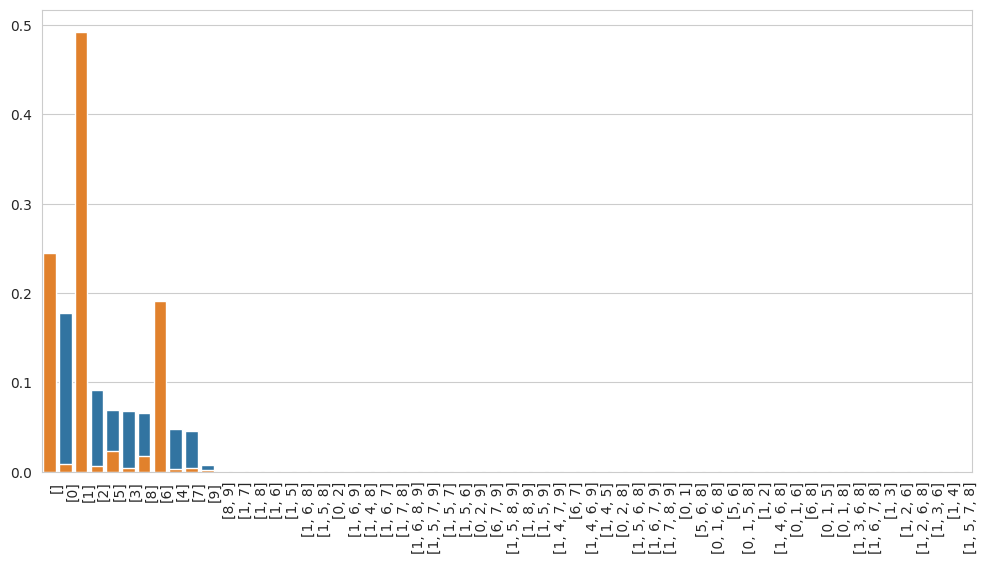

In [7]:
def plot_response_distribution(plotting_data, label):
    s = pd.Series(plotting_data)
    s = s / s.sum()
    sns.barplot(s.head(40), label=label)
    plt.xticks(rotation=90, ha="left")


plot_response_distribution(data["instances"][2]["positional_bias"]["response_distribution"], "positional bias")
plot_response_distribution(data["instances"][2]["semantic_consistency"]["response_distribution"], "semantic consistency")

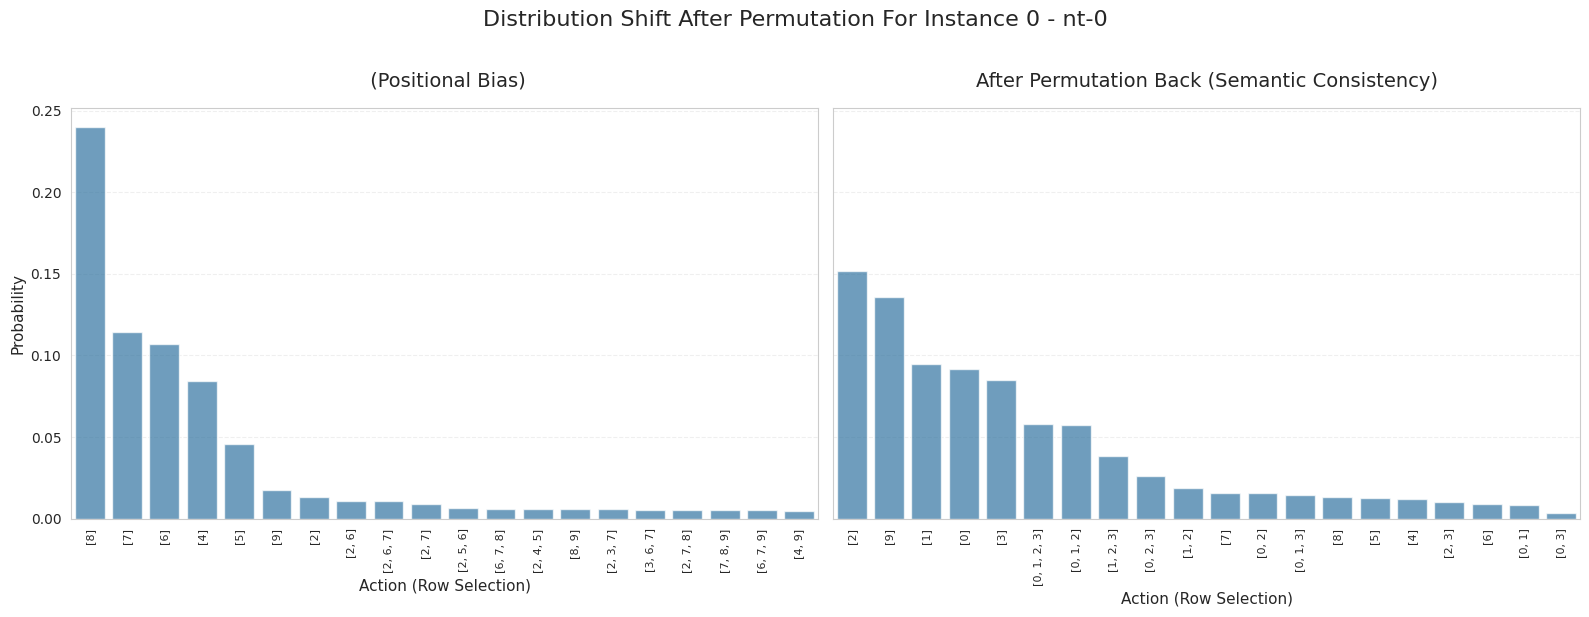

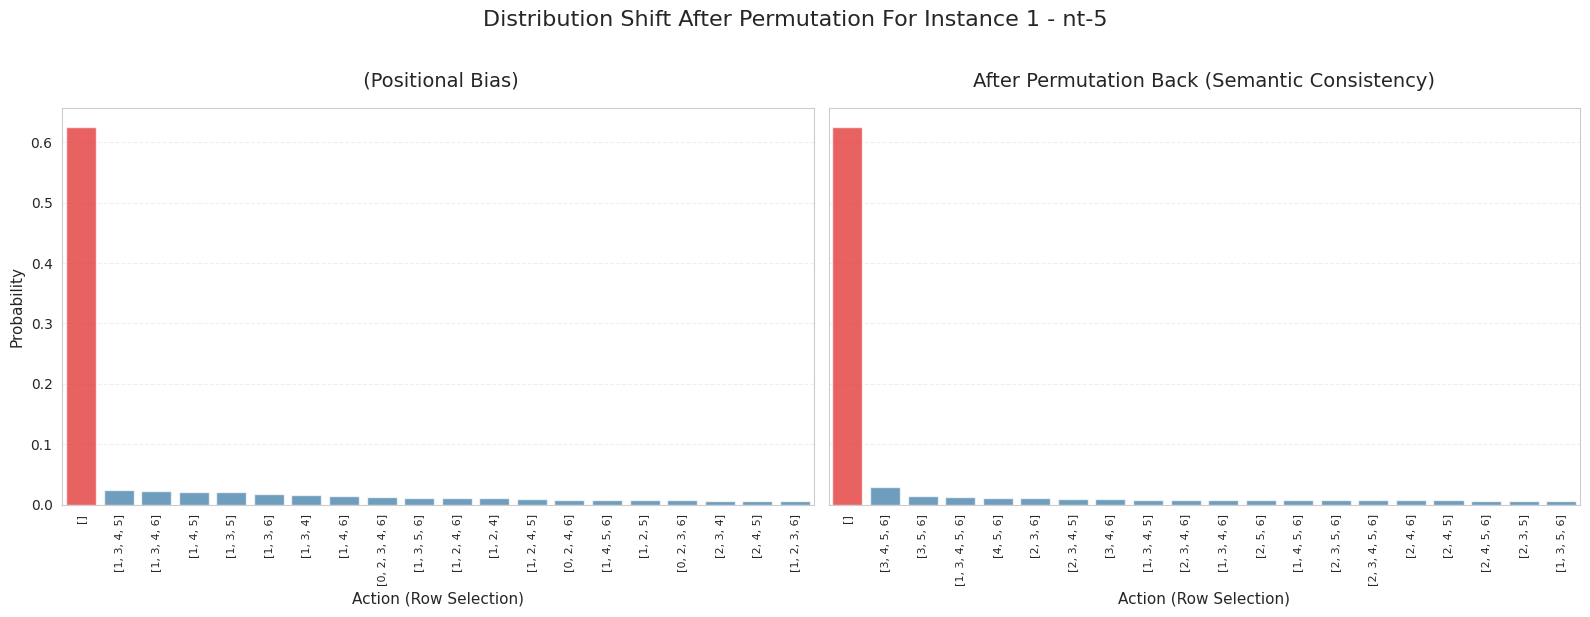

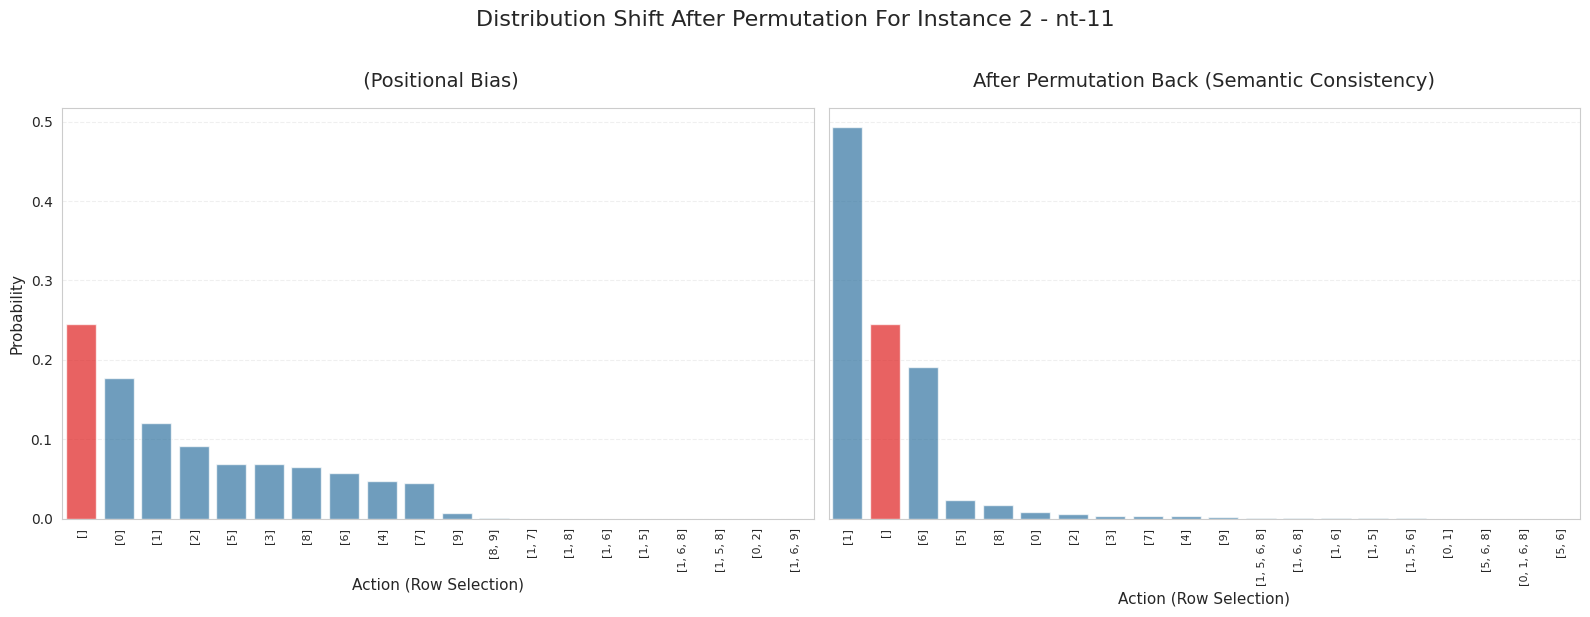

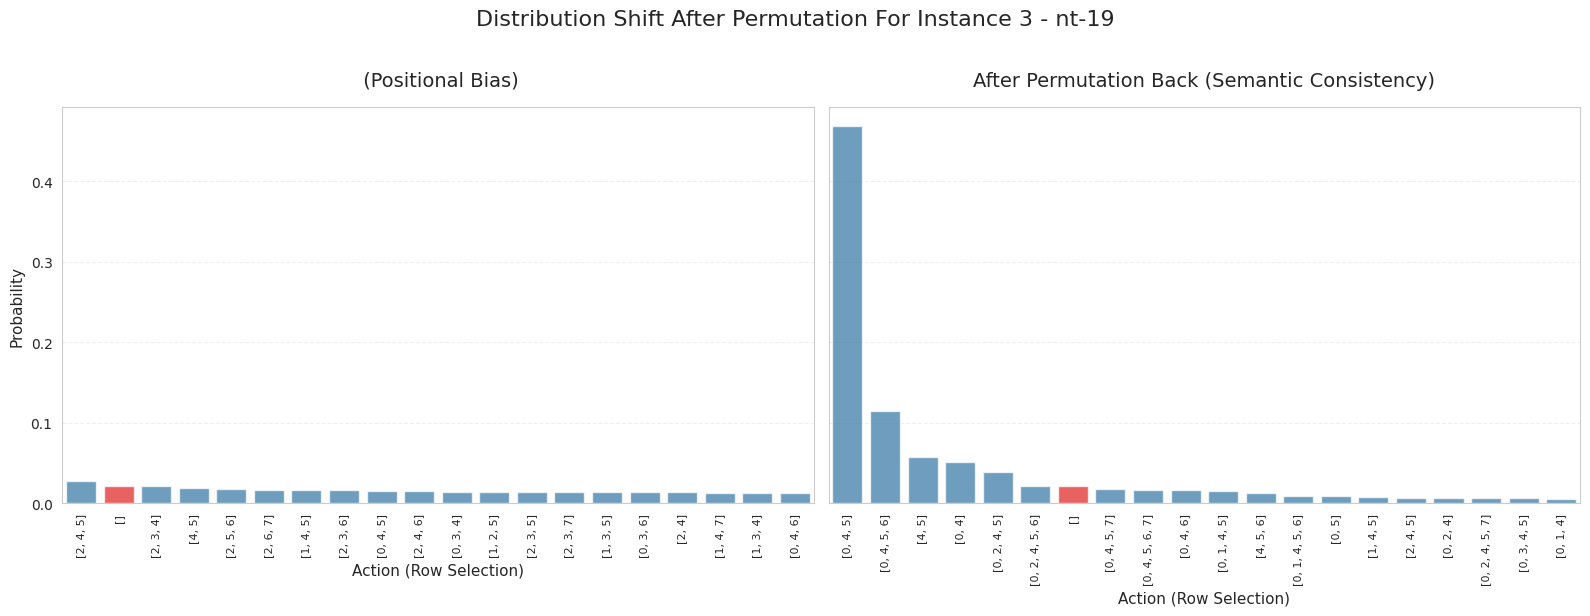

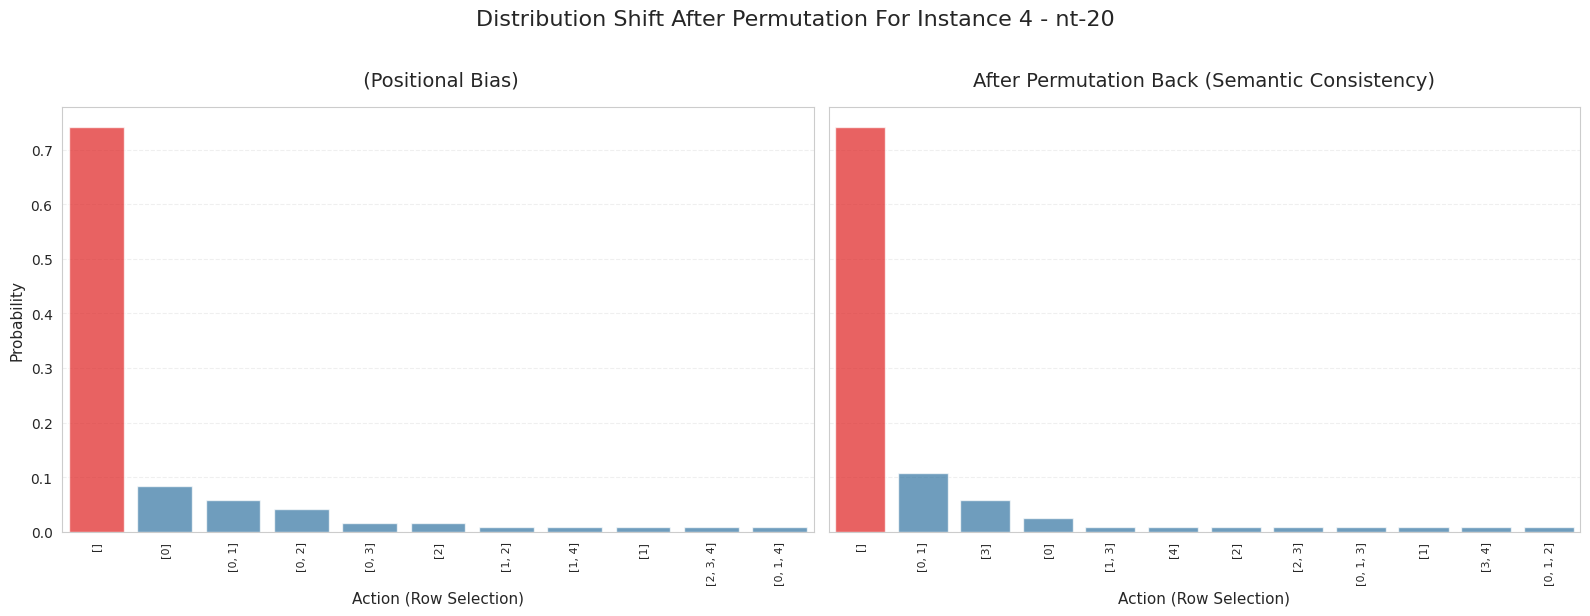

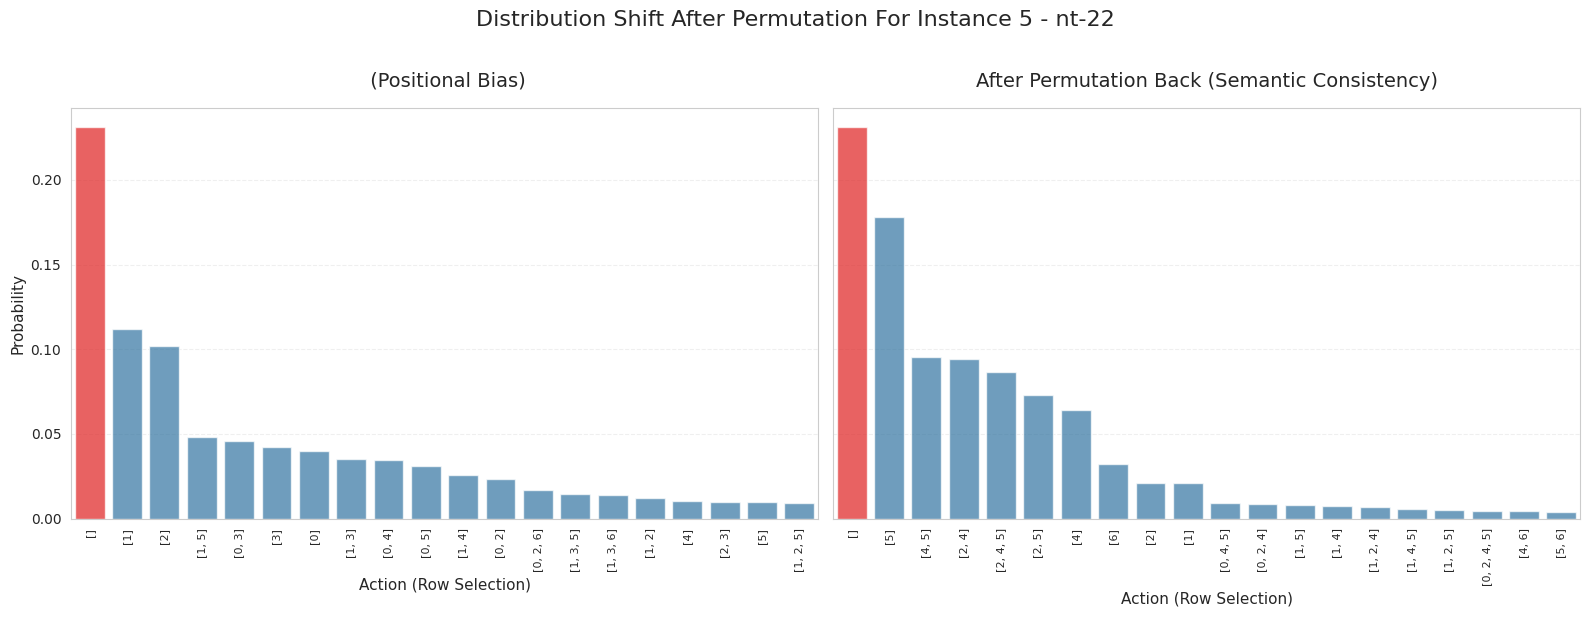

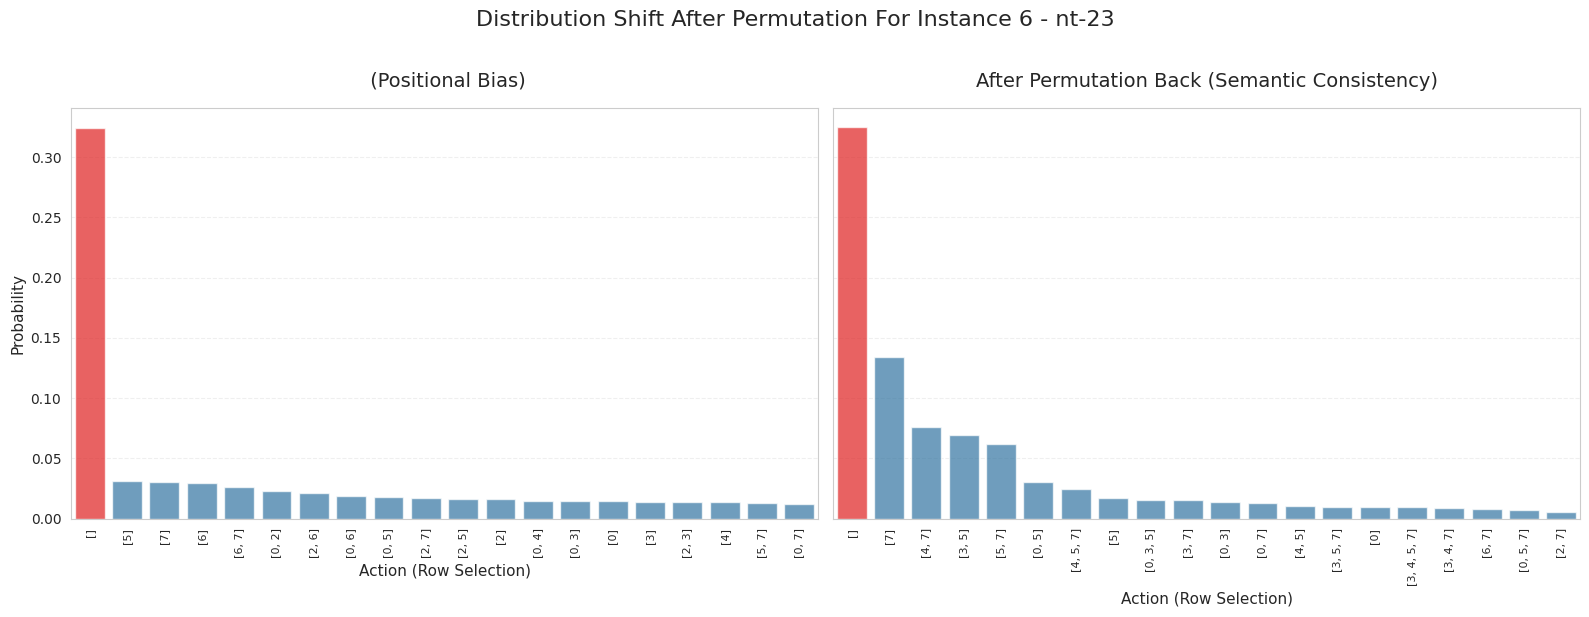

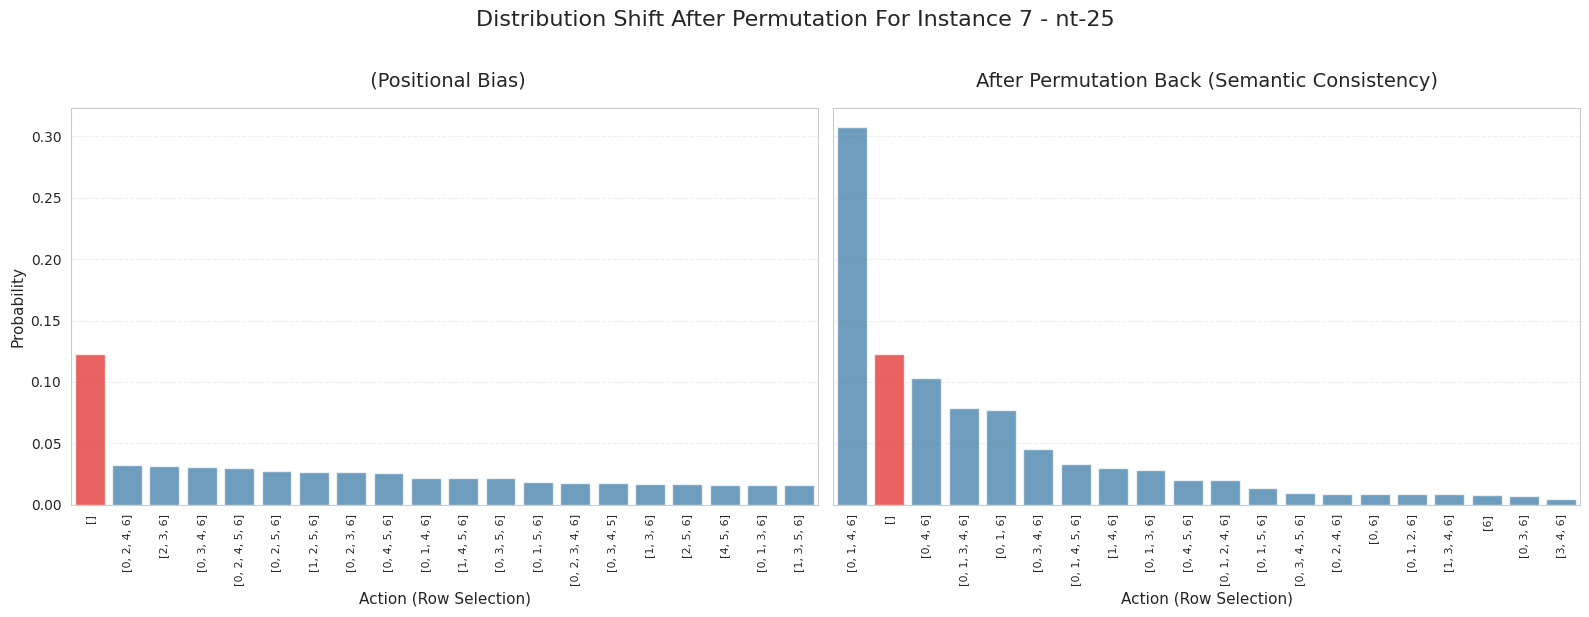

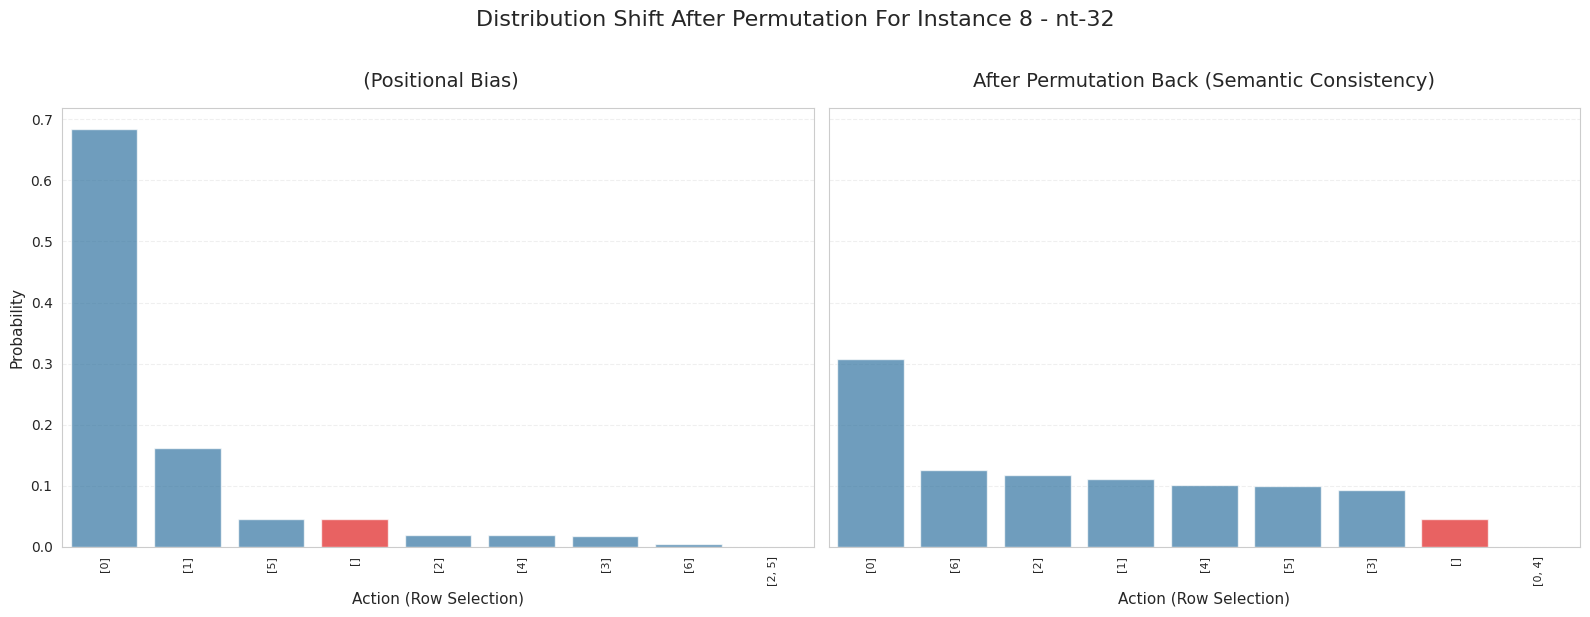

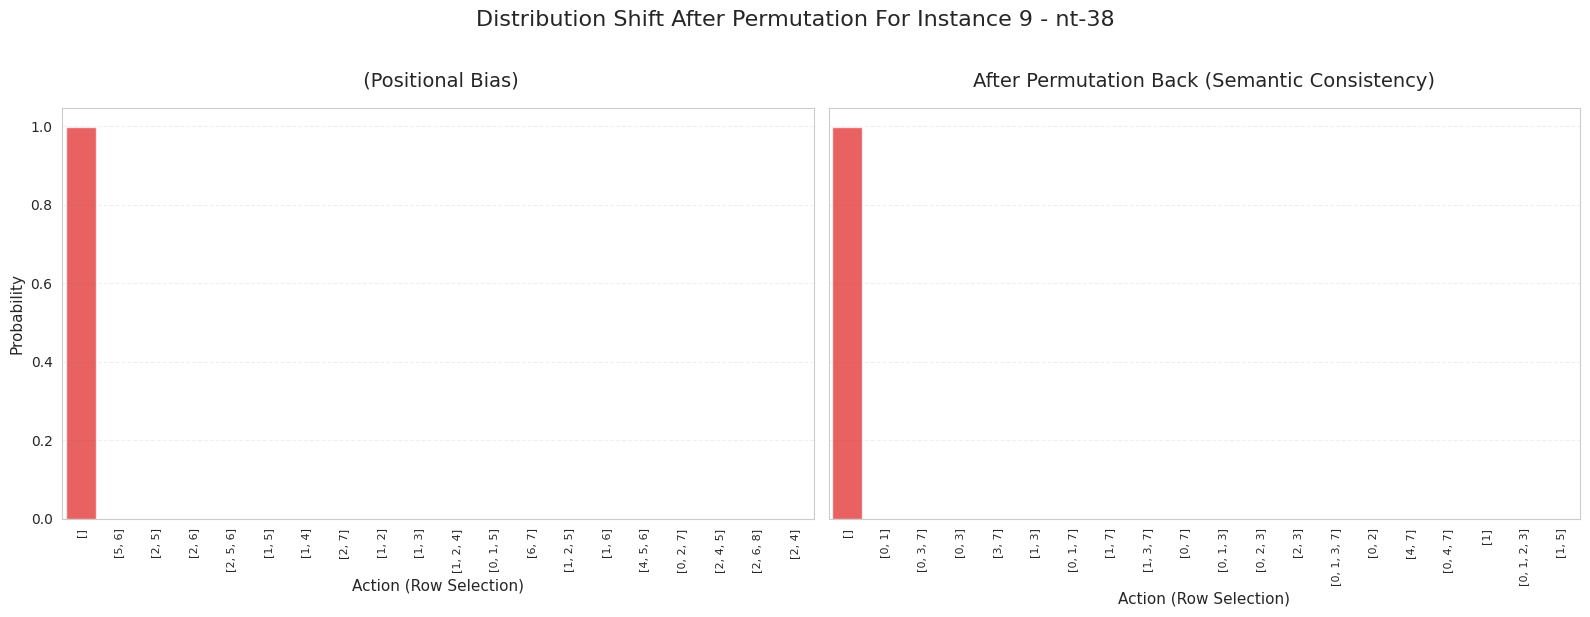

In [8]:
for i in range(len(data["instances"])):
    # Create comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, (key, title) in zip(
        axes, [("positional_bias", " (Positional Bias)"), ("semantic_consistency", "After Permutation Back (Semantic Consistency)")]
    ):
        dist = data["instances"][i][key]["response_distribution"]
        s = pd.Series(dist)
        s = s / s.sum()
        s = s.sort_values(ascending=False).head(20)

        # Create color array - red for "[]", default blue for others
        colors = ["red" if str(idx) == "[]" else "C0" for idx in s.index]

        sns.barplot(x=s.index, y=s.values, hue=s.index, ax=ax, alpha=0.7, palette=colors)
        ax.set_title(title, fontsize=14, pad=15)
        ax.set_xlabel("Action (Row Selection)", fontsize=11)
        ax.set_ylabel("Probability" if ax == axes[0] else "", fontsize=11)
        ax.tick_params(axis="x", rotation=90, labelsize=8)
        ax.grid(axis="y", alpha=0.3, linestyle="--")

    plt.suptitle(f"Distribution Shift After Permutation For Instance {i} - {data['instances'][i]['id']}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

1249

## Entropy Analysis of Response Distributions

In [ ]:
# Calculate entropy for each table's semantic consistency distribution
from scipy.stats import entropy as scipy_entropy


def calculate_entropy(response_distribution, num_permutations):
    """
    Calculate Shannon entropy of the response distribution.
    Higher entropy = more uniform distribution = more unpredictable
    Lower entropy = more concentrated distribution = more predictable
    """
    counts = np.array(list(response_distribution.values()))
    probabilities = counts / num_permutations
    # Calculate entropy in bits
    ent = scipy_entropy(probabilities, base=2)
    return ent


def calculate_max_entropy(num_unique_responses):
    """
    Calculate maximum possible entropy given number of unique responses.
    This occurs when all responses are equally likely.
    """
    return np.log2(num_unique_responses) if num_unique_responses > 0 else 0


def calculate_normalized_entropy(entropy, num_unique_responses):
    """
    Normalize entropy to [0, 1] range.
    0 = completely deterministic (one response always chosen)
    1 = completely uniform (all responses equally likely)
    """
    max_ent = calculate_max_entropy(num_unique_responses)
    return entropy / max_ent if max_ent > 0 else 0


print("=" * 80)
print("ENTROPY ANALYSIS: Response Distribution Predictability")
print("=" * 80)

entropy_data = []

for inst in data["instances"]:
    response_dist = inst["semantic_consistency"]["response_distribution"]
    num_perms = inst["num_permutations"]
    num_unique = inst["semantic_consistency"]["num_unique_responses"]

    # Calculate entropy metrics
    ent = calculate_entropy(response_dist, num_perms)
    max_ent = calculate_max_entropy(num_unique)
    normalized_ent = calculate_normalized_entropy(ent, num_unique)

    entropy_data.append(
        {
            "instance_idx": inst["instance_idx"],
            "id": inst["id"],
            "entropy": ent,
            "max_entropy": max_ent,
            "normalized_entropy": normalized_ent,
            "num_unique_responses": num_unique,
            "consistency": inst["semantic_consistency"]["consistency_percentage"],
        }
    )

    print(f"\nInstance {inst['instance_idx']}: {inst['id']}")
    print(f"  Unique responses: {num_unique:,}")
    print(f"  Entropy: {ent:.2f} bits")
    print(f"  Max possible entropy: {max_ent:.2f} bits")
    print(f"  Normalized entropy: {normalized_ent:.2%} (0=deterministic, 1=uniform)")
    print(f"  Semantic consistency: {inst['semantic_consistency']['consistency_percentage']:.2%}")

    # Interpretation
    if normalized_ent < 0.3:
        interpretation = "HIGHLY PREDICTABLE - responses concentrated in few answers"
    elif normalized_ent < 0.6:
        interpretation = "MODERATELY PREDICTABLE - some concentration but diverse"
    else:
        interpretation = "HIGHLY UNPREDICTABLE - responses widely distributed"
    print(f"  → {interpretation}")

df_entropy = pd.DataFrame(entropy_data)
print(f"\n{'=' * 80}")
print(f"Average normalized entropy: {df_entropy['normalized_entropy'].mean():.2%}")
print(f"{'=' * 80}")

In [ ]:
# Visualize entropy across instances
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. Entropy values
x = df_entropy["instance_idx"]
axes[0].bar(x, df_entropy["entropy"], alpha=0.7, color="purple", label="Actual Entropy")
axes[0].plot(x, df_entropy["max_entropy"], "r--", marker="o", label="Max Possible Entropy", linewidth=2)
axes[0].set_xlabel("Instance Index")
axes[0].set_ylabel("Entropy (bits)")
axes[0].set_title("Response Distribution Entropy\n(Higher = More unpredictable/diverse)")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
axes[0].set_xticks(x)

# 2. Normalized entropy
axes[1].bar(x, df_entropy["normalized_entropy"], alpha=0.7, color="teal")
axes[1].axhline(y=0.5, color="orange", linestyle="--", linewidth=2, label="50% of max entropy")
axes[1].set_xlabel("Instance Index")
axes[1].set_ylabel("Normalized Entropy")
axes[1].set_title("Normalized Entropy (0 = Deterministic, 1 = Uniform Distribution)")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
axes[1].set_xticks(x)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [ ]:
# Correlation: Entropy vs Consistency
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_entropy["consistency"], df_entropy["normalized_entropy"], s=100, alpha=0.6, c=df_entropy["instance_idx"], cmap="viridis"
)
ax.set_xlabel("Semantic Consistency (higher = more consistent)")
ax.set_ylabel("Normalized Entropy (higher = more diverse)")
ax.set_title("Relationship: Semantic Consistency vs Response Entropy")
ax.grid(True, alpha=0.3)

# Add labels for each point
for idx, row in df_entropy.iterrows():
    ax.annotate(
        f"I{row['instance_idx']}", (row["consistency"], row["normalized_entropy"]), xytext=(5, 5), textcoords="offset points", fontsize=9
    )

plt.colorbar(scatter, ax=ax, label="Instance Index")
plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("=" * 80)
print("Expected relationship: Higher consistency → Lower entropy")
print("- High consistency means one answer dominates → Low entropy (concentrated)")
print("- Low consistency means responses spread out → High entropy (diverse)")

# Calculate correlation
correlation = df_entropy["consistency"].corr(df_entropy["normalized_entropy"])
print(f"\nCorrelation coefficient: {correlation:.3f}")
if correlation < -0.5:
    print("→ Strong negative correlation (as expected)")
elif correlation < 0:
    print("→ Weak negative correlation")
else:
    print("→ Unexpected positive correlation!")